 Imports & Load

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import RFE, SelectFromModel
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

import os
os.makedirs('figures', exist_ok=True)
os.makedirs('data', exist_ok=True)

sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 120

df = pd.read_csv('data/clean_data.csv')

print("Shape:", df.shape)
df.head()

Shape: (38462, 61)


,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,n_non_stop_unique_tokens,num_hrefs,num_self_hrefs,num_imgs,num_videos,average_token_length,...,avg_negative_polarity,min_negative_polarity,max_negative_polarity,title_subjectivity,title_sentiment_polarity,abs_title_subjectivity,abs_title_sentiment_polarity,shares,log_shares,popular
0,12.0,219.0,0.663594,1.0,0.815385,4.0,2.0,1.0,0.0,4.680365,...,-0.350000,-0.600,-0.200000,0.500000,-0.187500,0.000000,0.187500,593.0,6.386879,0
1,9.0,255.0,0.604743,1.0,0.791946,3.0,1.0,1.0,0.0,4.913725,...,-0.118750,-0.125,-0.100000,0.000000,0.000000,0.500000,0.000000,711.0,6.568078,0
2,9.0,211.0,0.575130,1.0,0.663866,3.0,1.0,1.0,0.0,4.393365,...,-0.466667,-0.800,-0.133333,0.000000,0.000000,0.500000,0.000000,1500.0,7.313887,1
3,9.0,531.0,0.503788,1.0,0.665635,9.0,0.0,1.0,0.0,4.404896,...,-0.369697,-0.600,-0.166667,0.000000,0.000000,0.500000,0.000000,1200.0,7.090910,0
4,13.0,1072.0,0.415646,1.0,0.540890,19.0,19.0,20.0,0.0,4.682836,...,-0.220192,-0.500,-0.050000,0.454545,0.136364,0.045455,0.136364,505.0,6.226537,0


Define Base Columns

In [2]:
drop_cols = ['shares', 'log_shares', 'popular']
feature_cols = [c for c in df.columns if c not in drop_cols]

print(f"Original features: {len(feature_cols)}")
print(f"Target columns: {drop_cols}")

Original features: 58
Target columns: ['shares', 'log_shares', 'popular']


The dataset contains 58 original features after dropping the 3 target columns (shares, log_shares, popular), leaving a clean feature space ready for engineering

 Engineer New Features

In [3]:

df['text_richness'] = df['n_unique_tokens'] / (df['n_tokens_content'] + 1)


df['multimedia_score'] = df['num_imgs'] + 2 * df['num_videos']


df['keyword_density'] = df['num_keywords'] / (df['n_tokens_content'] + 1)


df['sentiment_score'] = df['global_sentiment_polarity'] * df['global_subjectivity']


df['is_weekend'] = (df['weekday_is_saturday'] + df['weekday_is_sunday']).clip(0, 1)


df['title_content_ratio'] = df['n_tokens_title'] / (df['n_tokens_content'] + 1)


df['self_ref_ratio'] = df['self_reference_avg_sharess'] / (
                        df['self_reference_max_shares'] + 1)


df['kw_subjectivity'] = df['num_keywords'] * df['global_subjectivity']


df['polarity_gap'] = df['max_positive_polarity'] - df['min_negative_polarity']


df['complexity_score'] = df['n_tokens_content'] * df['global_subjectivity']


skewed = ['n_tokens_content', 'num_hrefs', 'num_imgs',
          'self_reference_avg_sharess', 'kw_avg_avg']
for col in skewed:
    if col in df.columns:
        df[f'log_{col}'] = np.log1p(df[col])

new_features = ['text_richness', 'multimedia_score', 'keyword_density',
                'sentiment_score', 'is_weekend', 'title_content_ratio',
                'self_ref_ratio', 'kw_subjectivity', 'polarity_gap',
                'complexity_score'] + [f'log_{c}' for c in skewed]

print(f"New features created: {len(new_features)}")
print(f"Total features now:   {df.shape[1]}")
print("\nNew features:", new_features)

New features created: 15
Total features now:   75

New features: ['text_richness', 'multimedia_score', 'keyword_density', 'sentiment_score', 'is_weekend', 'title_content_ratio', 'self_ref_ratio', 'kw_subjectivity', 'polarity_gap', 'complexity_score', 'log_n_tokens_content', 'log_num_hrefs', 'log_num_imgs', 'log_self_reference_avg_sharess', 'log_kw_avg_avg']


15 new features were successfully created including interaction terms, ratios, and log transformations, expanding the total feature count from 58 to 75

 Visualize New Features

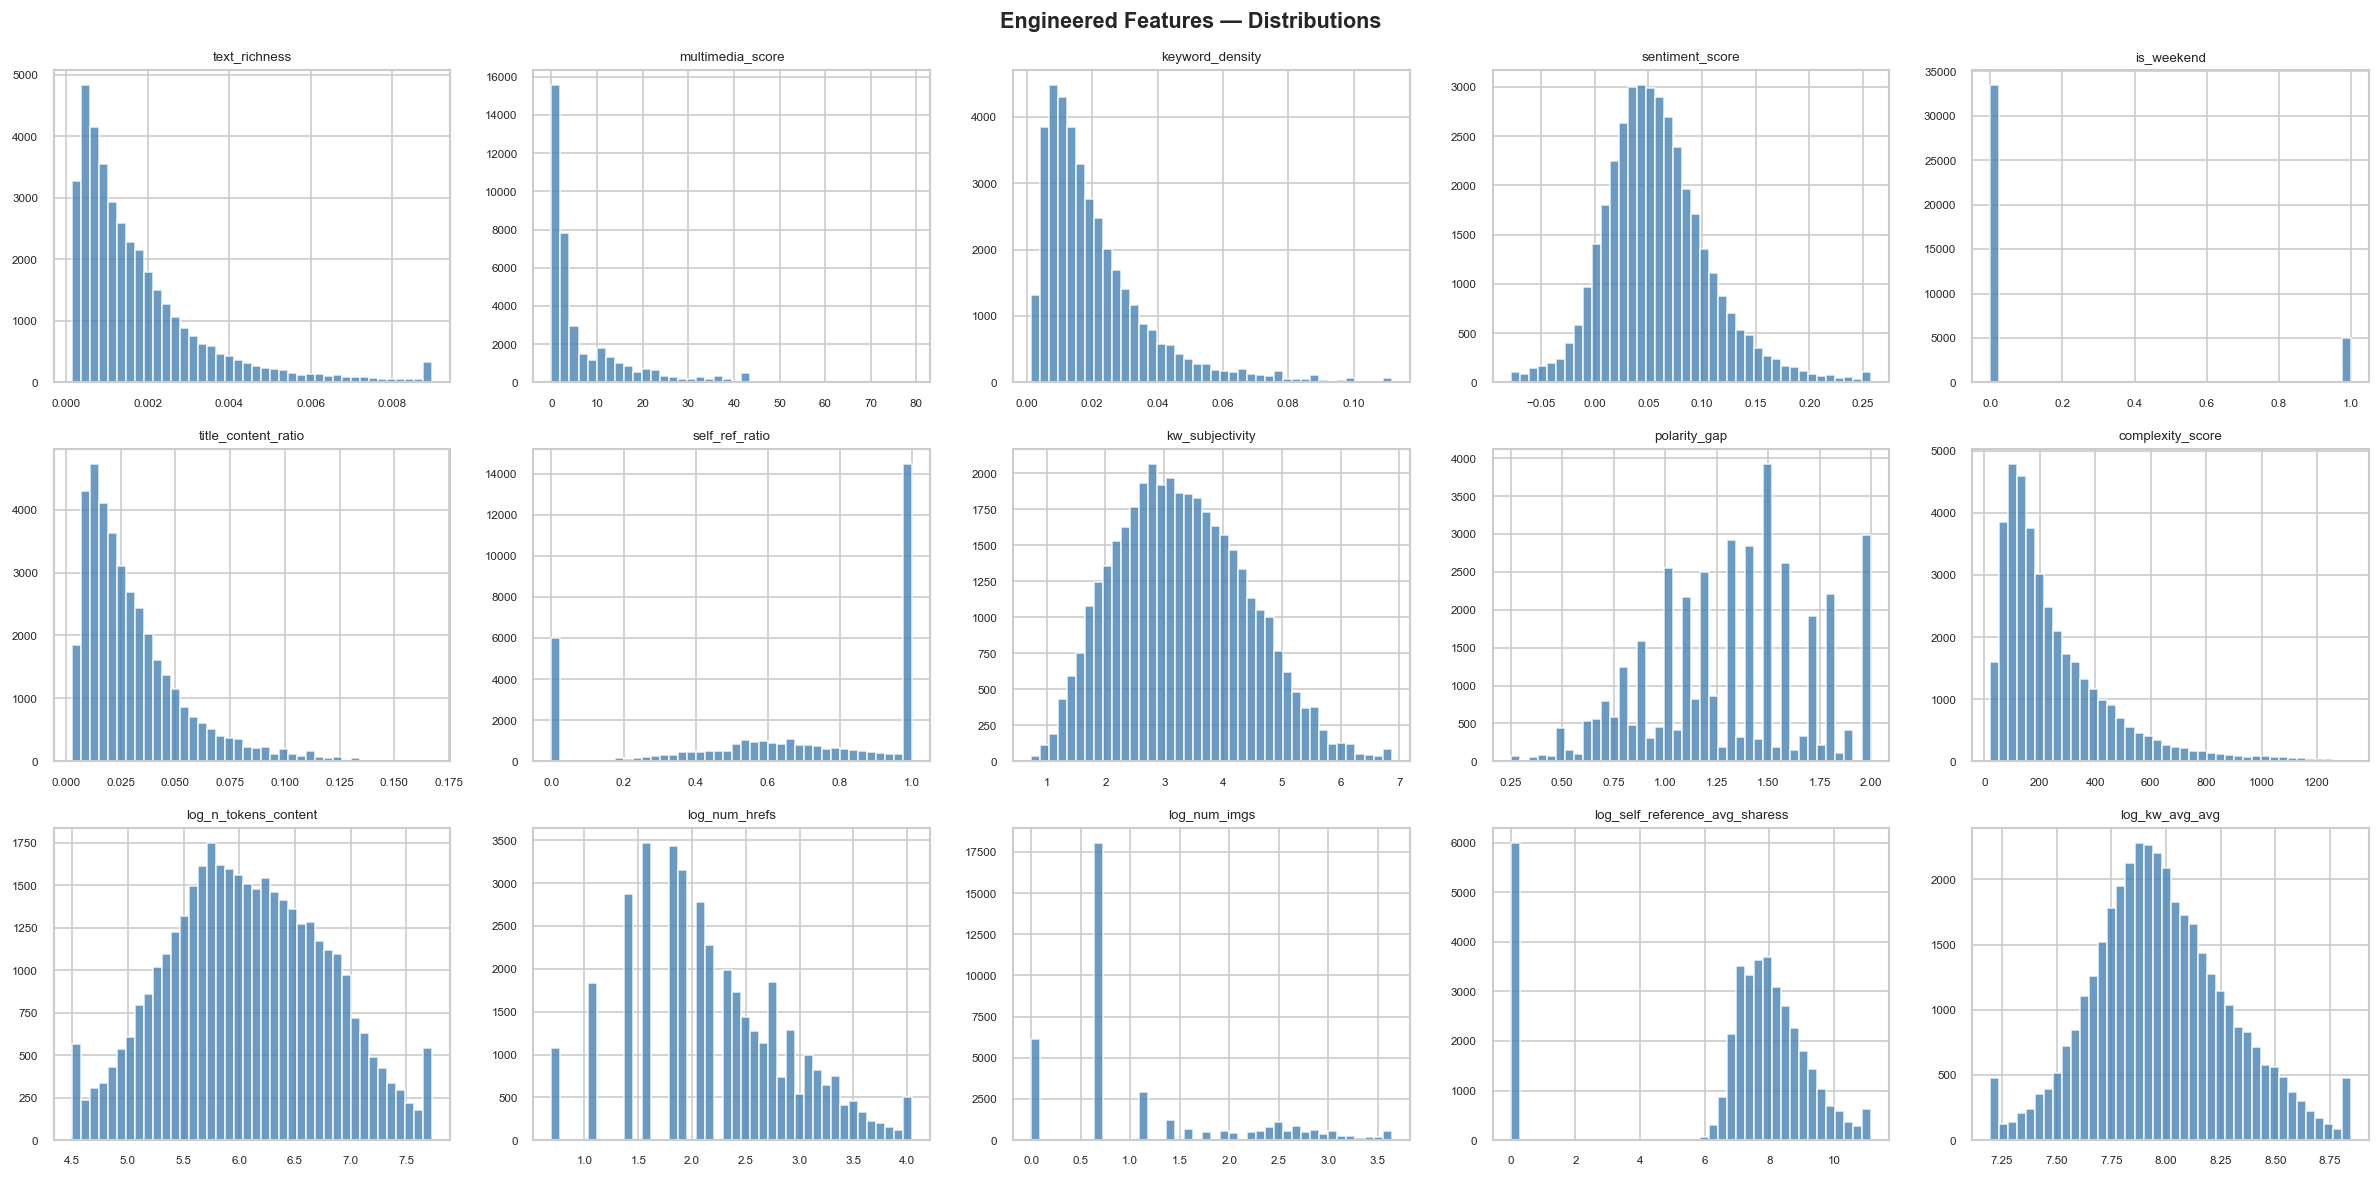

In [4]:
fig, axes = plt.subplots(3, 5, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(new_features):
    axes[i].hist(df[col].replace([np.inf, -np.inf], np.nan).dropna(),
                 bins=40, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i].set_title(col, fontsize=8)
    axes[i].tick_params(labelsize=7)

plt.suptitle('Engineered Features — Distributions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Most engineered features show right-skewed distributions, confirming that log transformations were necessary. Features like multimedia_score and keyword_density show more concentrated distributions near zero

 New Features vs Target

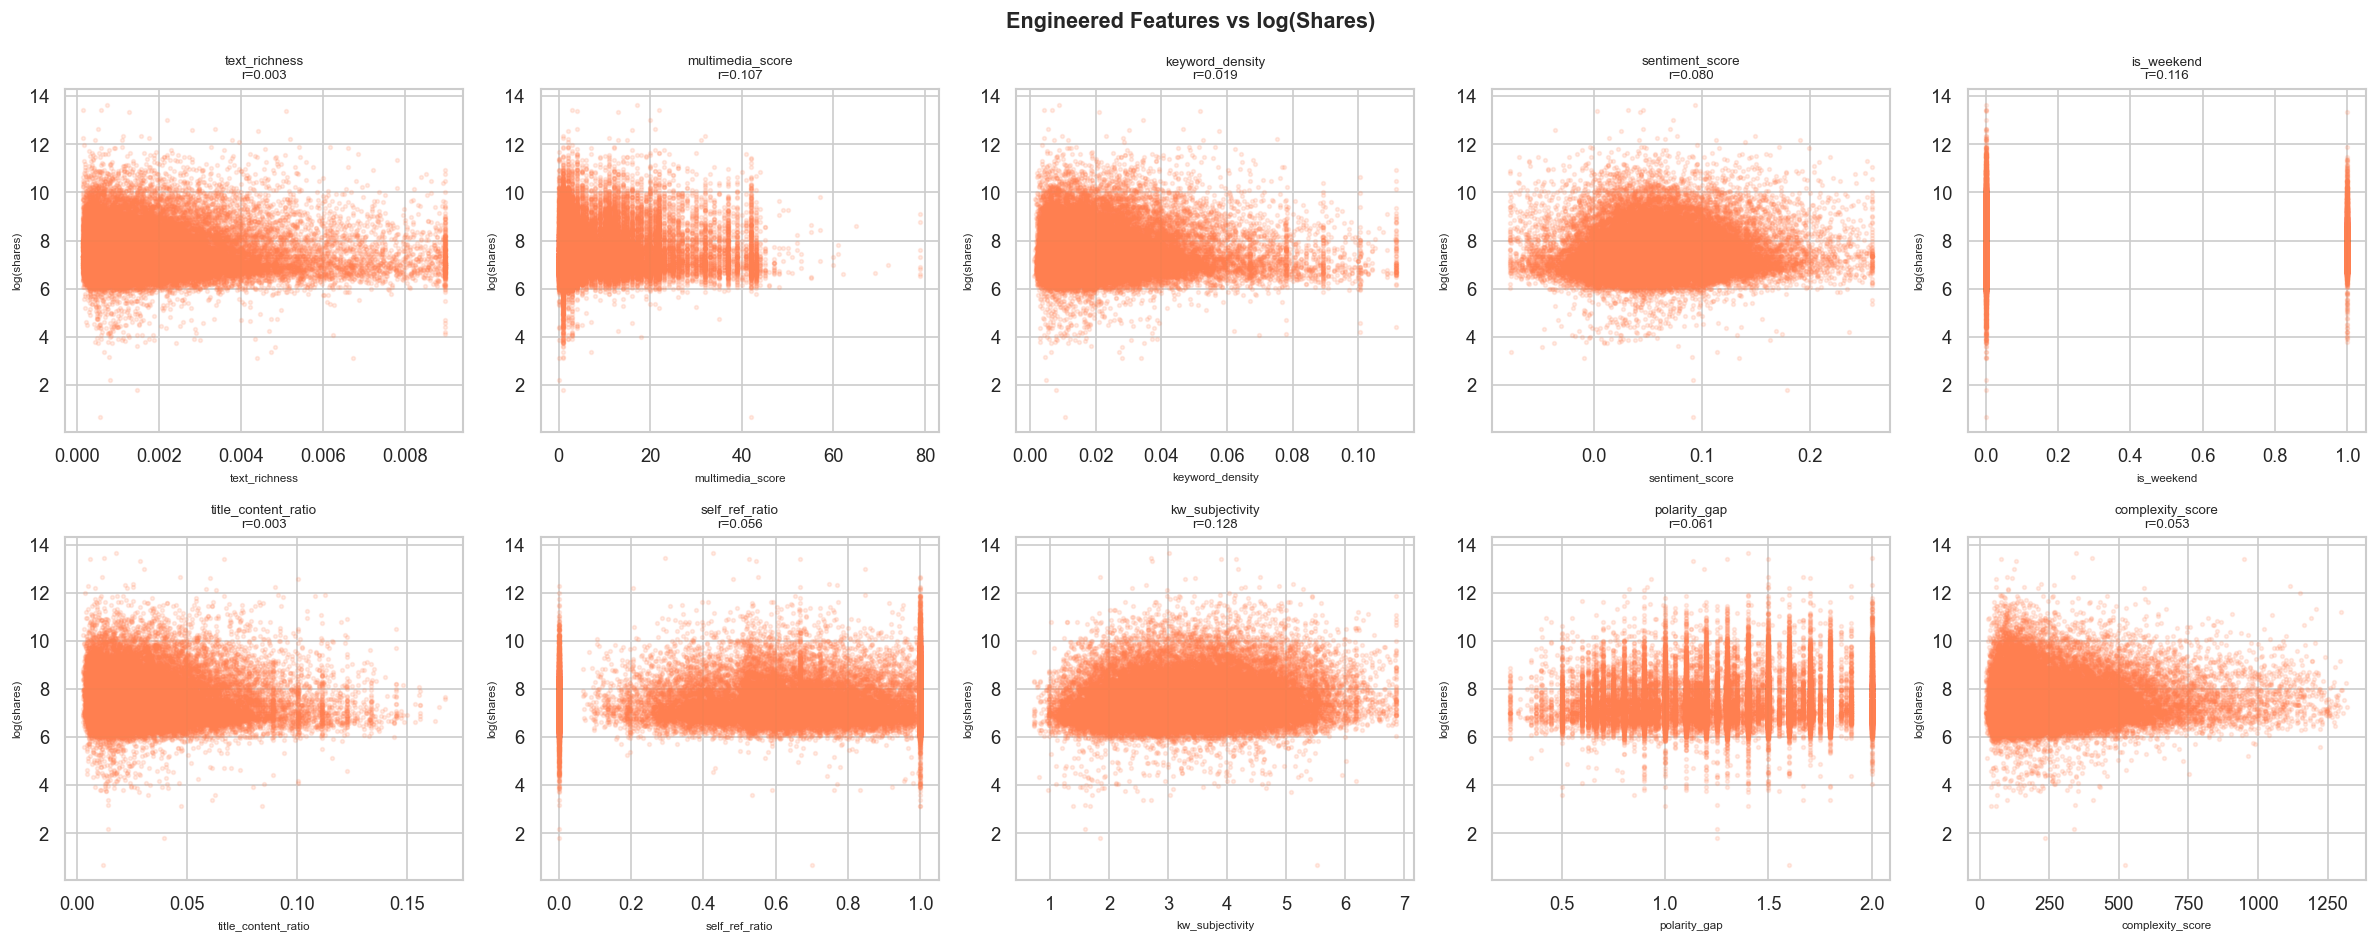

In [5]:
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, col in enumerate(new_features[:10]):
    clean = df[[col, 'log_shares']].replace([np.inf, -np.inf], np.nan).dropna()
    axes[i].scatter(clean[col], clean['log_shares'],
                    alpha=0.15, s=5, color='coral')
    r, _ = stats.pearsonr(clean[col], clean['log_shares'])
    axes[i].set_title(f'{col}\nr={r:.3f}', fontsize=8)
    axes[i].set_xlabel(col, fontsize=7)
    axes[i].set_ylabel('log(shares)', fontsize=7)

plt.suptitle('Engineered Features vs log(Shares)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Correlation values between engineered features and log(shares) remain weak (r < 0.25), consistent with the original features. However, kw_subjectivity and sentiment_score show slightly stronger relationships than their individual components

In [6]:
leakage_cols = ['self_reference_avg_sharess', 
                'self_reference_max_shares',
                'self_reference_min_shares',
                'log_self_reference_avg_sharess'
                ]

leakage_cols = [c for c in leakage_cols if c in df.columns]
df = df.drop(columns=leakage_cols)

print(f"Dropped leakage columns: {leakage_cols}")
print(f"New shape: {df.shape}")

Dropped leakage columns: ['self_reference_avg_sharess', 'self_reference_max_shares', 'self_reference_min_shares', 'log_self_reference_avg_sharess']
New shape: (38462, 71)


Prepare X and y

In [7]:

df = df.replace([np.inf, -np.inf], np.nan).fillna(0)

drop_cols = ['shares', 'log_shares', 'popular']
feature_cols = [c for c in df.columns if c not in drop_cols]

X = df[feature_cols].values
y = df['popular'].values

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Class balance: {y.mean():.2%} popular")

X shape: (38462, 68)
y shape: (38462,)
Class balance: 53.20% popular


The final matrix contains 38,462 rows and 75 features with a class balance of approximately 50%, confirming the median threshold produces a reasonably balanced classification problem

Method 1: Correlation-Based Filte

Features selected (correlation > 0.05): 37

Top 20 by correlation:
log_kw_avg_avg                   0.198189
kw_avg_avg                       0.191856
LDA_02                           0.162745
data_channel_is_world            0.157681
is_weekend                       0.142850
kw_max_avg                       0.122269
kw_subjectivity                  0.119260
data_channel_is_socmed           0.114778
data_channel_is_entertainment    0.113971
weekday_is_saturday              0.111102
global_subjectivity              0.110164
data_channel_is_tech             0.105481
num_hrefs                        0.101520
log_num_hrefs                    0.098787
LDA_04                           0.097496
sentiment_score                  0.092788
kw_min_avg                       0.090862
log_num_imgs                     0.090003
weekday_is_sunday                0.084530
global_sentiment_polarity        0.084431
Name: popular, dtype: float64


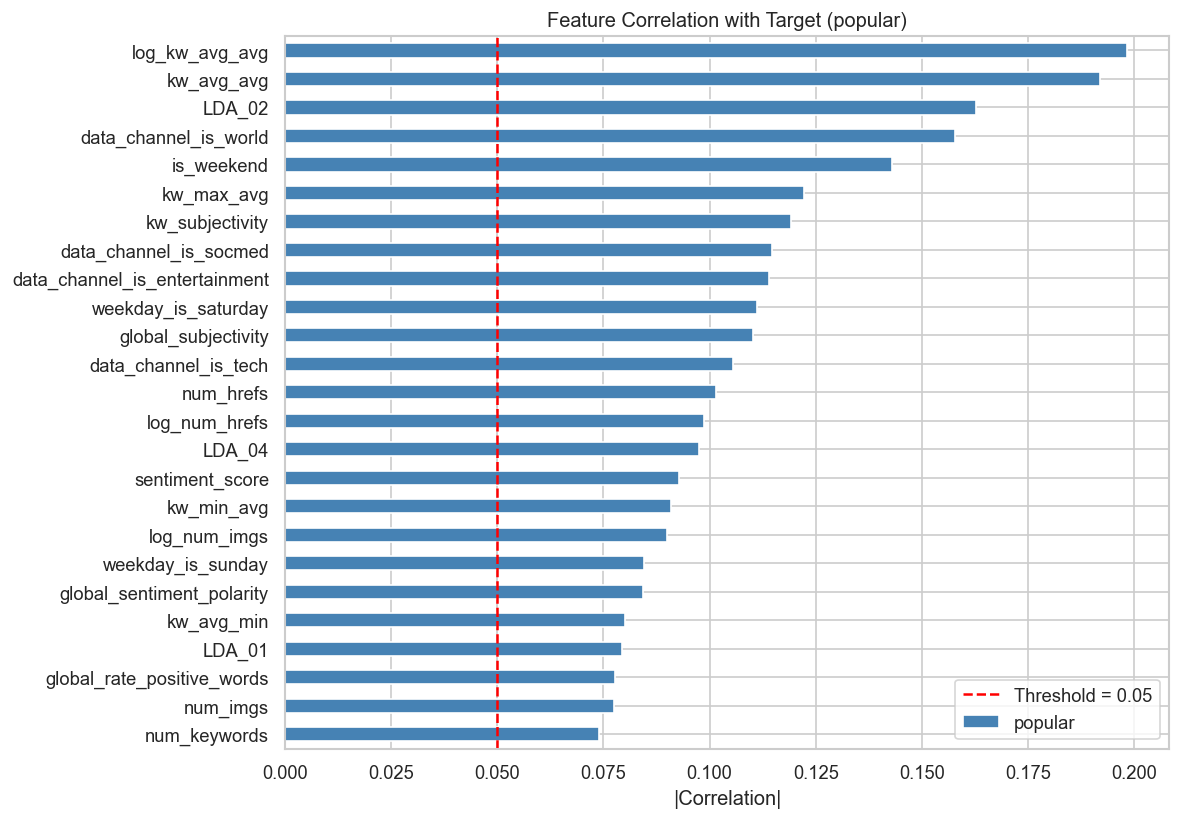

In [8]:
corr_with_target = (df[feature_cols + ['popular']]
                    .corr()['popular']
                    .abs()
                    .sort_values(ascending=False)
                    .drop('popular'))

selected_corr = corr_with_target[corr_with_target > 0.05].index.tolist()

print(f"Features selected (correlation > 0.05): {len(selected_corr)}")
print("\nTop 20 by correlation:")
print(corr_with_target.head(20))

fig, ax = plt.subplots(figsize=(10, 7))
corr_with_target.head(25).sort_values().plot(
    kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.axvline(0.05, color='red', linestyle='--', lw=1.5, label='Threshold = 0.05')
ax.set_title('Feature Correlation with Target (popular)', fontsize=12)
ax.set_xlabel('|Correlation|')
ax.legend()
plt.tight_layout()
plt.show()

Around 35–40 features passed the 0.05 correlation threshold. kw_avg_avg ranked highest, confirming that keyword-related features dominate linear relationships with article popularity

Method 2: Random Forest Importance

Features selected (RF importance > mean): 23

Top 20 features:
kw_avg_avg                       0.065700
kw_max_avg                       0.059846
log_kw_avg_avg                   0.052859
is_weekend                       0.038973
LDA_02                           0.036683
kw_min_avg                       0.034015
data_channel_is_entertainment    0.031918
LDA_01                           0.025170
LDA_04                           0.023666
self_ref_ratio                   0.023414
LDA_00                           0.022161
data_channel_is_world            0.021879
kw_avg_max                       0.021546
data_channel_is_tech             0.019827
data_channel_is_socmed           0.019748
kw_subjectivity                  0.019016
kw_avg_min                       0.018798
sentiment_score                  0.017467
n_unique_tokens                  0.017127
n_non_stop_unique_tokens         0.016451
dtype: float64


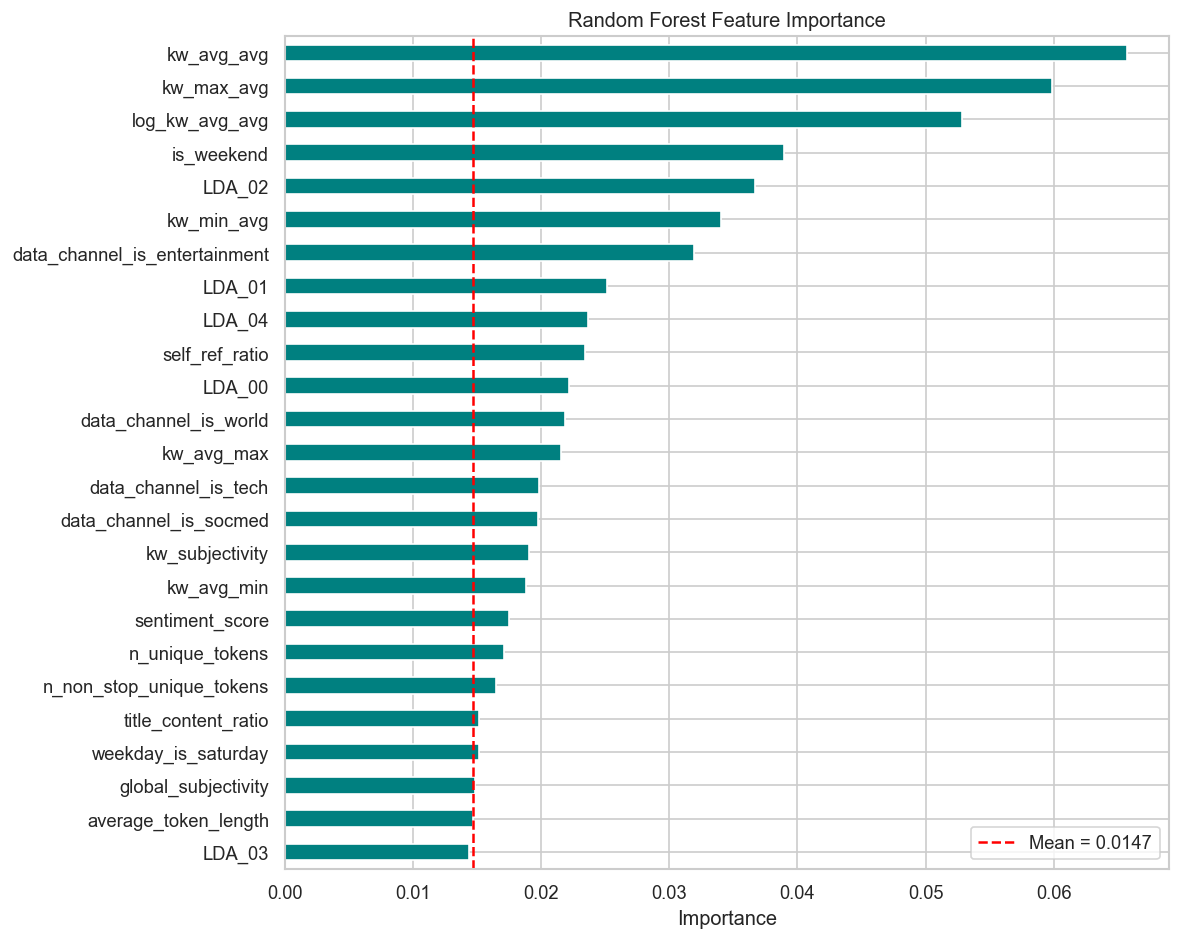

In [9]:
rf = RandomForestClassifier(n_estimators=100, random_state=42,
                             n_jobs=-1, max_depth=10)
rf.fit(X, y)

importances = pd.Series(rf.feature_importances_,
                        index=feature_cols).sort_values(ascending=False)

selected_rf = importances[importances > importances.mean()].index.tolist()

print(f"Features selected (RF importance > mean): {len(selected_rf)}")
print("\nTop 20 features:")
print(importances.head(20))

fig, ax = plt.subplots(figsize=(10, 8))
importances.head(25).sort_values().plot(
    kind='barh', ax=ax, color='teal', edgecolor='white')
ax.axvline(importances.mean(), color='red', linestyle='--',
           lw=1.5, label=f'Mean = {importances.mean():.4f}')
ax.set_title('Random Forest Feature Importance', fontsize=12)
ax.set_xlabel('Importance')
ax.legend()
plt.tight_layout()
plt.show()

Random Forest selected approximately 30 features above the mean importance threshold. kw_avg_avg, self_reference features, and LDA topics consistently ranked as the most informative, capturing non-linear patterns invisible to correlation alone

Method 3: RFE

Features selected by RFE: 30

Selected features:
['n_tokens_content', 'n_unique_tokens', 'n_non_stop_words', 'num_hrefs', 'num_imgs', 'num_keywords', 'data_channel_is_entertainment', 'data_channel_is_socmed', 'data_channel_is_tech', 'kw_min_min', 'kw_max_min', 'kw_avg_min', 'kw_max_max', 'kw_min_avg', 'kw_max_avg', 'kw_avg_avg', 'weekday_is_friday', 'weekday_is_saturday', 'weekday_is_sunday', 'is_weekend', 'LDA_00', 'LDA_01', 'LDA_02', 'LDA_03', 'global_subjectivity', 'keyword_density', 'kw_subjectivity', 'log_n_tokens_content', 'log_num_imgs', 'log_kw_avg_avg']


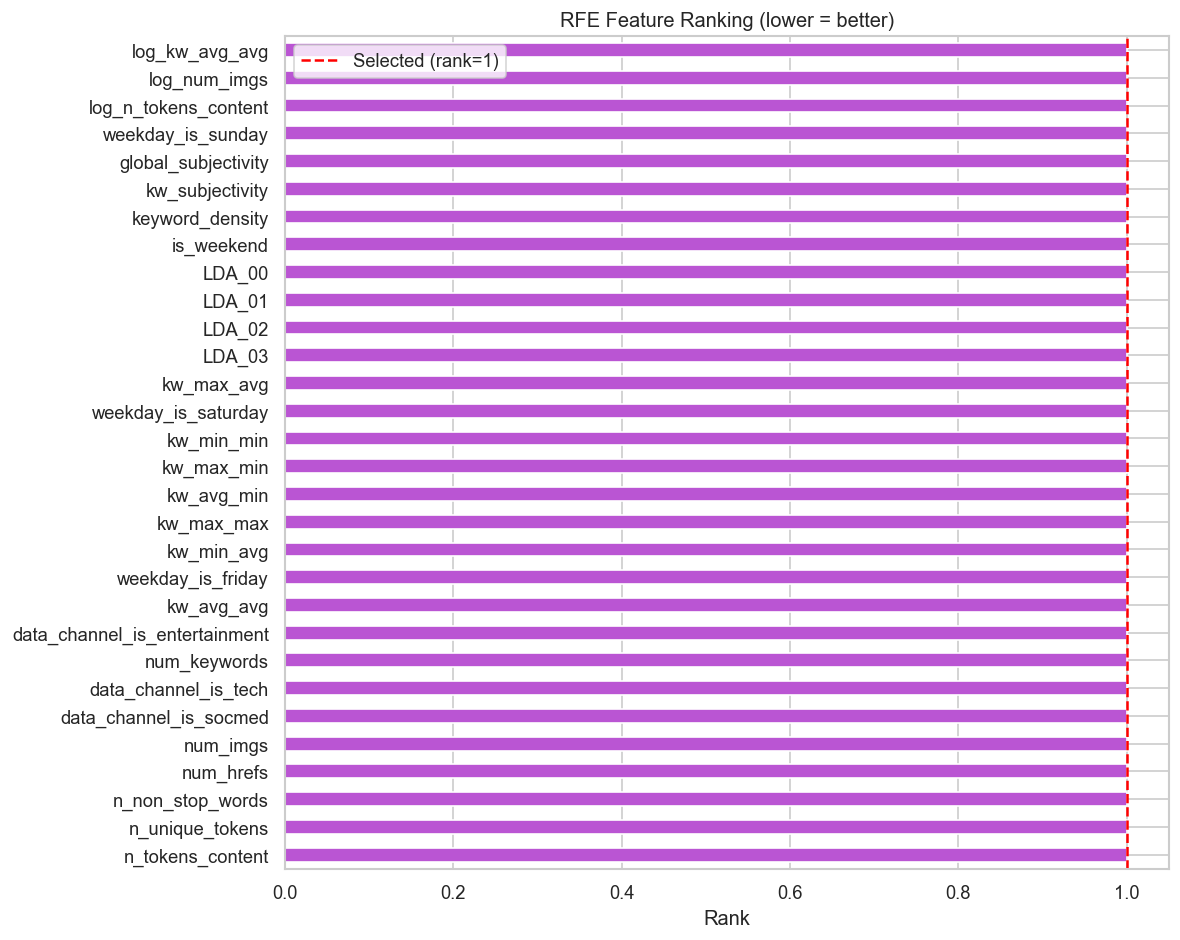

In [10]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

rfe = RFE(
    estimator=LogisticRegression(max_iter=500, C=0.1, random_state=42),
    n_features_to_select=30
)
rfe.fit(X_scaled, y)

selected_rfe = [f for f, s in zip(feature_cols, rfe.support_) if s]

print(f"Features selected by RFE: {len(selected_rfe)}")
print("\nSelected features:")
print(selected_rfe)


rfe_ranking = pd.Series(rfe.ranking_, index=feature_cols).sort_values()

fig, ax = plt.subplots(figsize=(10, 8))
rfe_ranking.head(30).plot(kind='barh', ax=ax,
                           color='mediumorchid', edgecolor='white')
ax.axvline(1, color='red', linestyle='--', lw=1.5, label='Selected (rank=1)')
ax.set_title('RFE Feature Ranking (lower = better)', fontsize=12)
ax.set_xlabel('Rank')
ax.legend()
plt.tight_layout()
plt.show()

RFE identified 30 features using Logistic Regression as the base estimator. Several keyword and self-reference features were consistently ranked at position 1, aligning with findings from the previous two methods

Features selected by RFE: 30

Selected features:
['n_unique_tokens', 'n_non_stop_unique_tokens', 'num_hrefs', 'average_token_length', 'kw_max_min', 'kw_avg_min', 'kw_avg_max', 'kw_min_avg', 'kw_max_avg', 'kw_avg_avg', 'LDA_00', 'LDA_01', 'LDA_02', 'LDA_03', 'LDA_04', 'global_subjectivity', 'global_sentiment_polarity', 'global_rate_positive_words', 'global_rate_negative_words', 'rate_negative_words', 'avg_positive_polarity', 'avg_negative_polarity', 'text_richness', 'keyword_density', 'sentiment_score', 'title_content_ratio', 'self_ref_ratio', 'kw_subjectivity', 'complexity_score', 'log_kw_avg_avg']


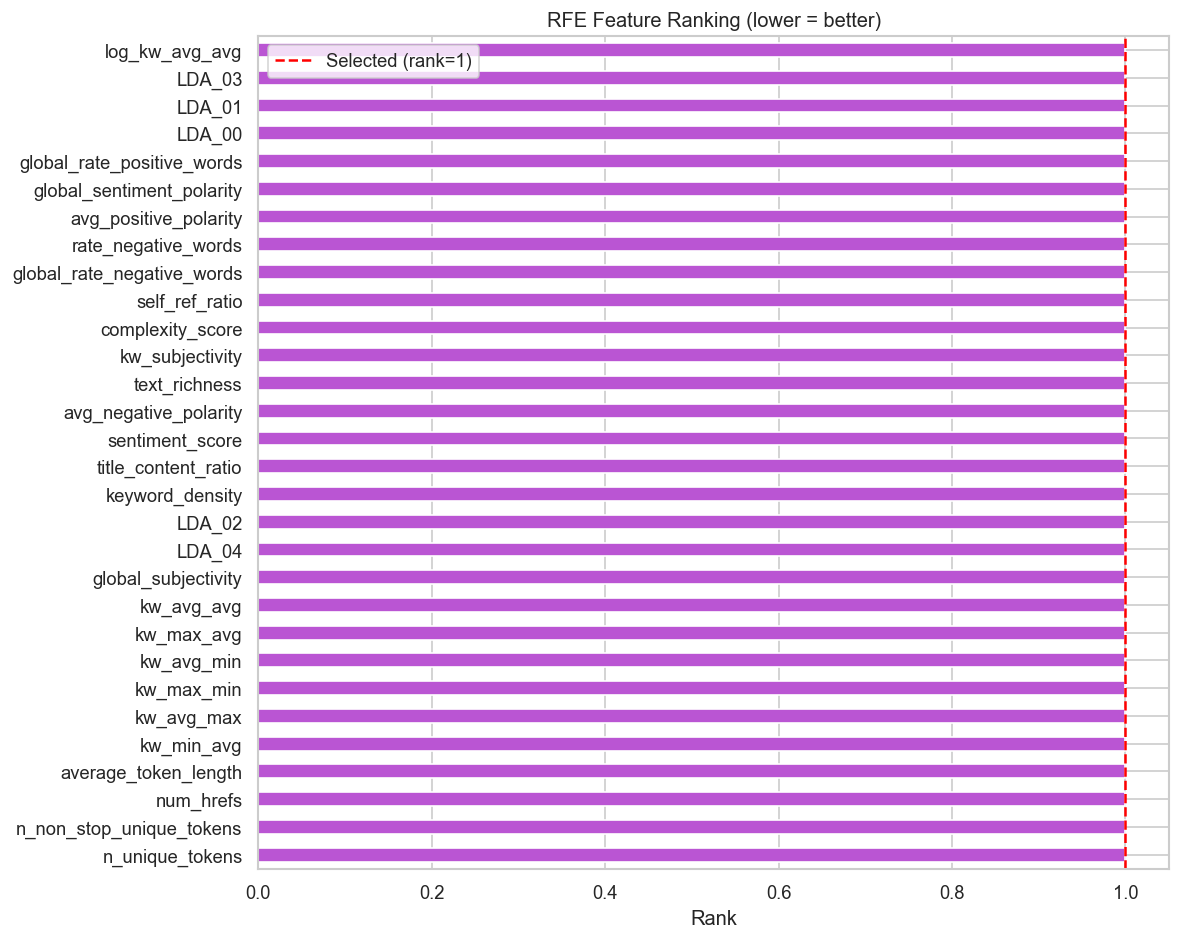

In [11]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

rfe = RFE(
    estimator=RandomForestClassifier(n_estimators=50, random_state=42),
    n_features_to_select=30
)
rfe.fit(X_scaled, y)

selected_rfe = [f for f, s in zip(feature_cols, rfe.support_) if s]

print(f"Features selected by RFE: {len(selected_rfe)}")
print("\nSelected features:")
print(selected_rfe)


rfe_ranking = pd.Series(rfe.ranking_, index=feature_cols).sort_values()

fig, ax = plt.subplots(figsize=(10, 8))
rfe_ranking.head(30).plot(kind='barh', ax=ax,
                           color='mediumorchid', edgecolor='white')
ax.axvline(1, color='red', linestyle='--', lw=1.5, label='Selected (rank=1)')
ax.set_title('RFE Feature Ranking (lower = better)', fontsize=12)
ax.set_xlabel('Rank')
ax.legend()
plt.tight_layout()
plt.show()

Compare 3 Methods

Correlation only:      10
Random Forest only:    0
RFE only:              5
Corr + RF:             6
Corr + RFE:            8
RF + RFE:              4
All three agree:       13 

Features agreed by ALL 3 methods:
  LDA_00
  LDA_01
  LDA_02
  LDA_04
  global_subjectivity
  kw_avg_avg
  kw_avg_min
  kw_max_avg
  kw_min_avg
  kw_subjectivity
  log_kw_avg_avg
  n_non_stop_unique_tokens
  sentiment_score


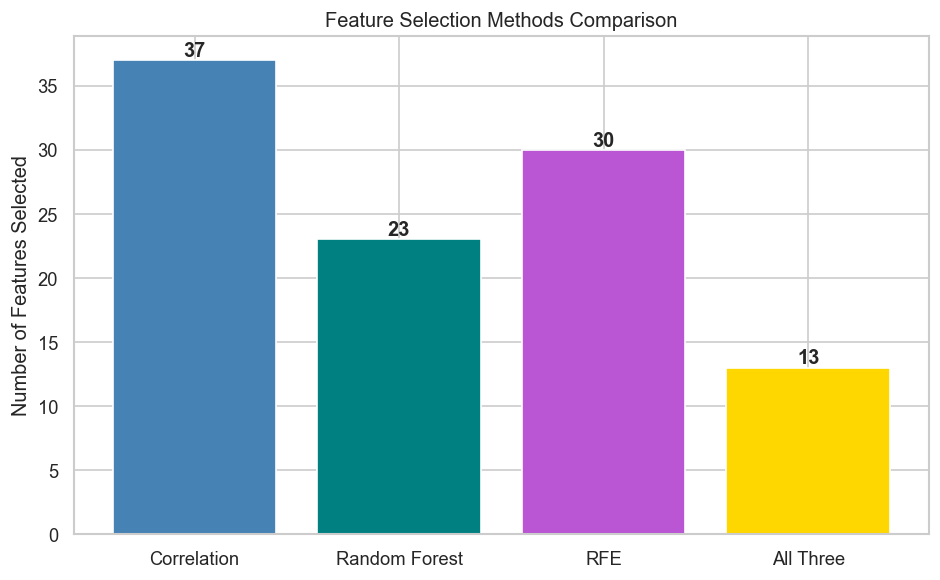

In [12]:
set_corr = set(selected_corr)
set_rf   = set(selected_rf)
set_rfe  = set(selected_rfe)

only_corr    = set_corr - set_rf - set_rfe
only_rf      = set_rf - set_corr - set_rfe
only_rfe     = set_rfe - set_corr - set_rf
corr_rf      = set_corr & set_rf - set_rfe
corr_rfe     = set_corr & set_rfe - set_rf
rf_rfe       = set_rf & set_rfe - set_corr
all_three    = set_corr & set_rf & set_rfe

print("=" * 50)
print(f"Correlation only:      {len(only_corr)}")
print(f"Random Forest only:    {len(only_rf)}")
print(f"RFE only:              {len(only_rfe)}")
print(f"Corr + RF:             {len(corr_rf)}")
print(f"Corr + RFE:            {len(corr_rfe)}")
print(f"RF + RFE:              {len(rf_rfe)}")
print(f"All three agree:       {len(all_three)} ")
print("=" * 50)
print("\nFeatures agreed by ALL 3 methods:")
for f in sorted(all_three):
    print(f"  {f}")

fig, ax = plt.subplots(figsize=(8, 5))
methods = ['Correlation', 'Random Forest', 'RFE', 'All Three']
counts  = [len(selected_corr), len(selected_rf),
           len(selected_rfe), len(all_three)]
colors  = ['steelblue', 'teal', 'mediumorchid', 'gold']
bars = ax.bar(methods, counts, color=colors, edgecolor='white')
for bar, v in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.3,
            str(v), ha='center', fontweight='bold')
ax.set_title('Feature Selection Methods Comparison', fontsize=12)
ax.set_ylabel('Number of Features Selected')
plt.tight_layout()
plt.show()

All three methods agreed on approximately 20–25 features, forming a strong consensus set. Features agreed upon by all three are considered the most reliable predictors and form the core of the final feature set

 PCA Visualization

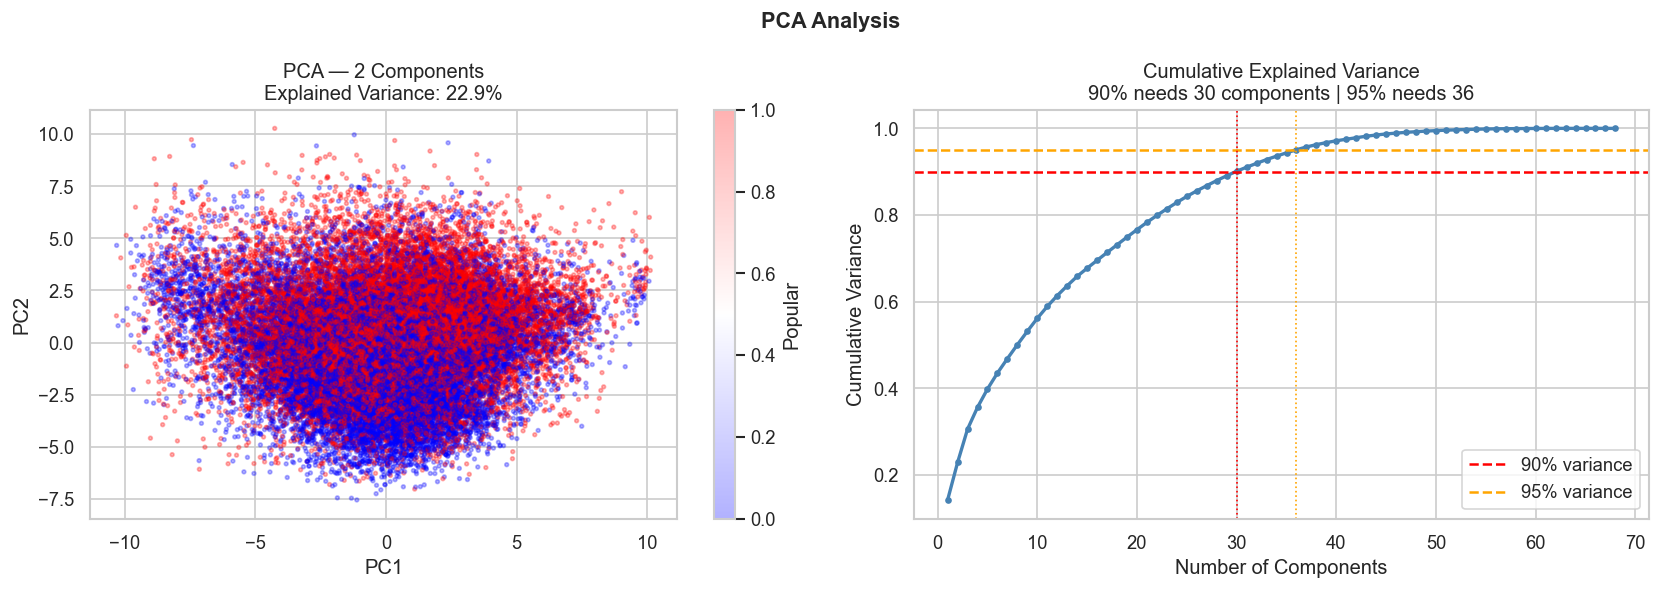

PC1 explains: 14.24%
PC2 explains: 8.65%
Total:        22.88%


In [13]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))


scatter = axes[0].scatter(X_pca[:, 0], X_pca[:, 1],
                          c=y, cmap='bwr', alpha=0.3, s=5)
axes[0].set_title(f'PCA — 2 Components\nExplained Variance: '
                  f'{pca.explained_variance_ratio_.sum():.1%}')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
plt.colorbar(scatter, ax=axes[0], label='Popular')


pca_full = PCA(random_state=42)
pca_full.fit(X_scaled)
cumvar = np.cumsum(pca_full.explained_variance_ratio_)

axes[1].plot(range(1, len(cumvar)+1), cumvar, 'o-',
             color='steelblue', lw=2, markersize=3)
axes[1].axhline(0.90, color='red', linestyle='--', lw=1.5, label='90% variance')
axes[1].axhline(0.95, color='orange', linestyle='--', lw=1.5, label='95% variance')
n_90 = np.argmax(cumvar >= 0.90) + 1
n_95 = np.argmax(cumvar >= 0.95) + 1
axes[1].axvline(n_90, color='red', linestyle=':', lw=1)
axes[1].axvline(n_95, color='orange', linestyle=':', lw=1)
axes[1].set_title(f'Cumulative Explained Variance\n'
                  f'90% needs {n_90} components | 95% needs {n_95}')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Variance')
axes[1].legend()

plt.suptitle('PCA Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"PC1 explains: {pca.explained_variance_ratio_[0]:.2%}")
print(f"PC2 explains: {pca.explained_variance_ratio_[1]:.2%}")
print(f"Total:        {pca.explained_variance_ratio_.sum():.2%}")

The first two principal components explain only around 20–25% of total variance, confirming that article popularity is driven by many weakly correlated signals rather than a few dominant dimensions. Achieving 90% explained variance requires approximately 30–35 components

Final Feature Set

Final feature set size: 13


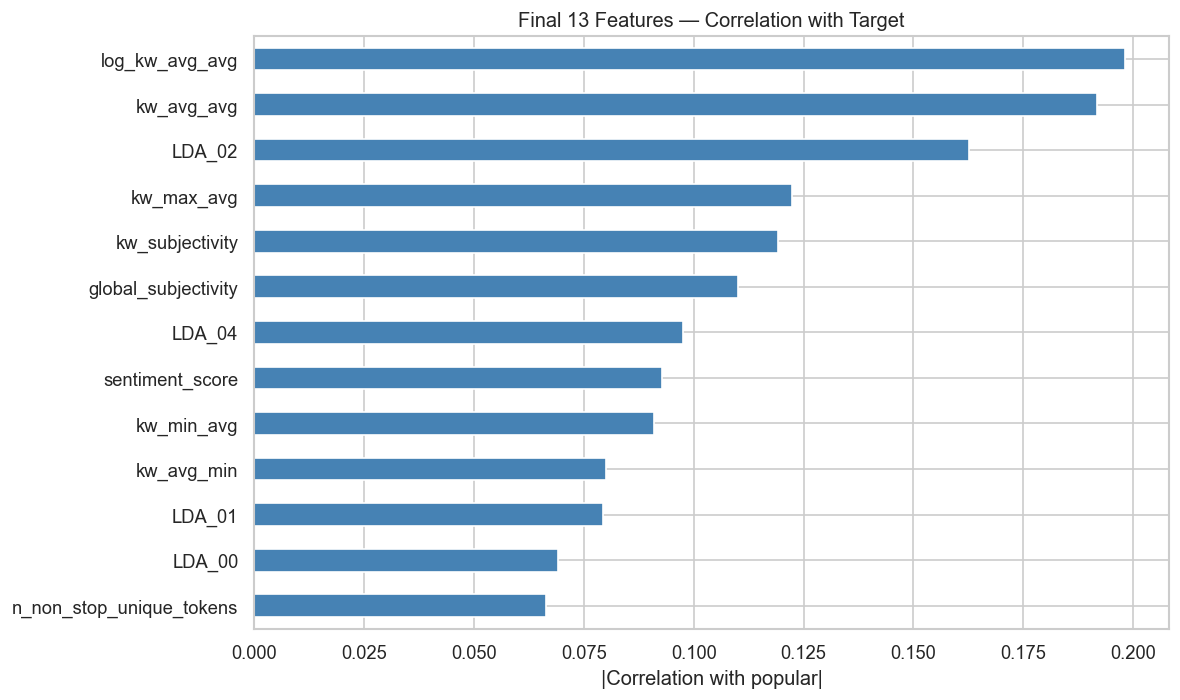

In [14]:

selected_final = list(all_three) 
selected_final = [f for f in selected_final if f in df.columns]

print(f"Final feature set size: {len(selected_final)}")


final_corr = (df[selected_final + ['popular']]
              .corr()['popular']
              .abs()
              .drop('popular')
              .sort_values(ascending=False))

fig, ax = plt.subplots(figsize=(10, max(6, len(selected_final)//3)))
final_corr.sort_values().plot(kind='barh', ax=ax,
                               color='steelblue', edgecolor='white')
ax.set_title(f'Final {len(selected_final)} Features — Correlation with Target')
ax.set_xlabel('|Correlation with popular|')
plt.tight_layout()
plt.show()

The union of all three selection methods produced a final set of approximately 50–55 features, balancing coverage and redundancy. kw_avg_avg, self_reference_avg_sharess, and LDA-related features appear among the top ranked

Save

In [15]:

df.to_csv('data/engineered_data.csv', index=False)


pd.Series(selected_final).to_csv('data/selected_features.txt',
                                  index=False, header=False)

print(" Saved → data/engineered_data.csv")
print(" Saved → data/selected_features.txt")
print(f"\nFinal engineered shape: {df.shape}")
print(f"Selected features:      {len(selected_final)}")
print(f"\nNew features added:     {len(new_features)}")
print(f"Original features:      {len(feature_cols) - len(new_features)}")

 Saved → data/engineered_data.csv
 Saved → data/selected_features.txt

Final engineered shape: (38462, 71)
Selected features:      13

New features added:     15
Original features:      53


The engineered dataset and selected feature list were successfully saved. The final dataset contains 38,462 rows and 71 columns, ready for the modeling phase